# Wide spectroscopy comparison

Compare the broad-square sweep with the latest Lorentzian sweep as side-by-side color plots.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
import numpy as np
from scipy.optimize import curve_fit

from bundle_utils import amp_prefactor_to_rabi_amp_mhz, extract_qubit_variables
from presentation_style import polish_axes, use_presentation_style

use_presentation_style()

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data" / "broad_sqaure"
FIGURES_DIR = PROJECT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
FIT_WINDOW_MHZ = 100

def gaussian(x, offset, amplitude, center, sigma):
    return offset + amplitude * np.exp(-0.5 * ((x - center) / sigma) ** 2)

def fit_gaussian_fwhm(detuning_mhz, trace):
    y = np.asarray(trace, dtype=float)
    if np.nanmax(y) - np.nanmin(y) < 0.02:
        return None
    offset0 = float(np.nanmin(y))
    amplitude0 = float(np.nanmax(y) - offset0)
    center0 = float(detuning_mhz[int(np.nanargmax(y))])
    span = float(detuning_mhz.max() - detuning_mhz.min())
    step = float(np.nanmedian(np.diff(detuning_mhz)))
    sigma0 = max(span / 20, abs(step), 1e-6)
    try:
        params, _ = curve_fit(
            gaussian,
            detuning_mhz,
            y,
            p0=[offset0, amplitude0, center0, sigma0],
            bounds=(
                [0, 0, float(detuning_mhz.min()), abs(step) / 10],
                [1.5, 2.0, float(detuning_mhz.max()), span],
            ),
            maxfev=20000,
        )
    except RuntimeError:
        return None
    offset, amplitude, center, sigma = params
    fwhm = 2 * np.sqrt(2 * np.log(2)) * abs(sigma)
    return {
        "offset": float(offset),
        "amplitude": float(amplitude),
        "center_mhz": float(center),
        "sigma_mhz": float(abs(sigma)),
        "fwhm_mhz": float(fwhm),
        "left_mhz": float(center - fwhm / 2),
        "right_mhz": float(center + fwhm / 2),
    }

def fit_sweep_fwhm(sweep):
    data = sweep["data"]
    detuning_mhz = data.detuning_hz / 1e6
    fit_mask = np.abs(detuning_mhz) <= FIT_WINDOW_MHZ
    fit_detuning_mhz = detuning_mhz[fit_mask]
    left = []
    right = []
    amp = []
    fits = []
    for amp_index, rabi_amp in enumerate(sweep["rabi_amp_mhz"]):
        fit_trace = data.result[:, amp_index][fit_mask]
        fit = fit_gaussian_fwhm(fit_detuning_mhz, fit_trace)
        if fit is None:
            continue
        left.append(fit["left_mhz"])
        right.append(fit["right_mhz"])
        amp.append(float(rabi_amp))
        fits.append(fit)
    sweep["fwhm_left_mhz"] = np.asarray(left)
    sweep["fwhm_right_mhz"] = np.asarray(right)
    sweep["fwhm_rabi_amp_mhz"] = np.asarray(amp)
    sweep["gaussian_fits"] = fits

bundle_paths = sorted(DATA_DIR.glob("*_data_bundle.npz"))
if len(bundle_paths) < 2:
    raise FileNotFoundError(f"Expected at least two data bundles in {DATA_DIR}")

SWEEPS = []
for path in bundle_paths:
    data = extract_qubit_variables(path)
    frequency_span_mhz = data.parameters.get("frequency_span_in_mhz", np.nan)
    peak_amplitude = data.parameters.get("lorentzian_peak_amplitude", 1.0)
    effective_amp = data.amp_prefactor * peak_amplitude
    rabi_amp_mhz = amp_prefactor_to_rabi_amp_mhz(
        effective_amp,
        data.pi_pulse["amplitude"],
        data.pi_pulse["length_ns"],
    )
    SWEEPS.append(
        {
            "path": path,
            "data": data,
            "frequency_span_mhz": frequency_span_mhz,
            "peak_amplitude": peak_amplitude,
            "rabi_amp_mhz": rabi_amp_mhz,
        }
    )

SWEEPS = sorted(SWEEPS, key=lambda sweep: sweep["frequency_span_mhz"], reverse=True)
for index, sweep in enumerate(SWEEPS):
    sweep["label"] = "Broad domain" if index == 0 else "Zoom in" if index == 1 else f"Sweep {index + 1}"
    fit_sweep_fwhm(sweep)

metadata = SWEEPS[-1]["data"].metadata
parameters = SWEEPS[-1]["data"].parameters
qubit_name = SWEEPS[-1]["data"].qubit_name
t2_ramsey_ns = SWEEPS[-1]["data"].qubit_profile["transmon"]["t2_ramsey_ns"]/4
t2_limit_fwhm_mhz = 1000 / (np.pi * t2_ramsey_ns)


print(f"Qubit {qubit_name} has T2 limit of {t2_limit_fwhm_mhz:.3f} MHz (from T2 Ramsey = {t2_ramsey_ns:.3f} ns)")
t2_limit_half_width_mhz = t2_limit_fwhm_mhz / 2
[(sweep["label"], sweep["path"].name, sweep["frequency_span_mhz"], len(sweep["gaussian_fits"])) for sweep in SWEEPS]

Qubit q1 has T2 limit of 0.043 MHz (from T2 Ramsey = 7317.500 ns)


[('Broad domain', 'echo_lorentzian_18-38-50-690621_data_bundle.npz', 100, 100),
 ('Zoom in', 'echo_lorentzian_09-20-54-425808_data_bundle.npz', 1, 100)]

In [2]:
for sweep in SWEEPS:
    data = sweep["data"]
    pi_pulse = data.pi_pulse
    print(f"{sweep['label']}: {sweep['path']}")
    print(f"  Qubit: {data.qubit_name}")
    print(f"  Frequency span: {sweep['frequency_span_mhz']:g} MHz")
    print(f"  Qubit f01: {data.qubit_f01_hz / 1e9:.6f} GHz")
    print(f"  Lorentzian peak amplitude: {sweep['peak_amplitude']:g}")
    print(f"  Pi pulse: {data.pi_pulse_name}, amp={pi_pulse['amplitude']:.9f}, length={pi_pulse['length_ns']} ns")
    print(f"  Rabi scale: {amp_prefactor_to_rabi_amp_mhz(1, pi_pulse['amplitude'], pi_pulse['length_ns']):.3f} MHz per amplitude unit")
    print(f"  Result shape: {data.result.shape} = detuning x amp_prefactor")
    print(f"  Gaussian FWHM fits: {len(sweep['gaussian_fits'])} amplitude slices within +/-{FIT_WINDOW_MHZ:g} MHz")
print(f"T2 Ramsey: {t2_ramsey_ns:g} ns")
print(f"T2-limited FWHM: {t2_limit_fwhm_mhz:.5f} MHz")

Broad domain: c:\Users\owner\Developer\ips_plots\data\broad_sqaure\echo_lorentzian_18-38-50-690621_data_bundle.npz
  Qubit: q1
  Frequency span: 100 MHz
  Qubit f01: 4.267128 GHz
  Lorentzian peak amplitude: 0.2
  Pi pulse: x180_const, amp=0.161594380, length=40 ns
  Rabi scale: 77.354 MHz per amplitude unit
  Result shape: (1001, 100) = detuning x amp_prefactor
  Gaussian FWHM fits: 100 amplitude slices within +/-100 MHz
Zoom in: c:\Users\owner\Developer\ips_plots\data\broad_sqaure\echo_lorentzian_09-20-54-425808_data_bundle.npz
  Qubit: q1
  Frequency span: 1 MHz
  Qubit f01: 4.267128 GHz
  Lorentzian peak amplitude: 0.001
  Pi pulse: x180_const, amp=0.161594380, length=40 ns
  Rabi scale: 77.354 MHz per amplitude unit
  Result shape: (1001, 100) = detuning x amp_prefactor
  Gaussian FWHM fits: 100 amplitude slices within +/-100 MHz
T2 Ramsey: 7317.5 ns
T2-limited FWHM: 0.04350 MHz


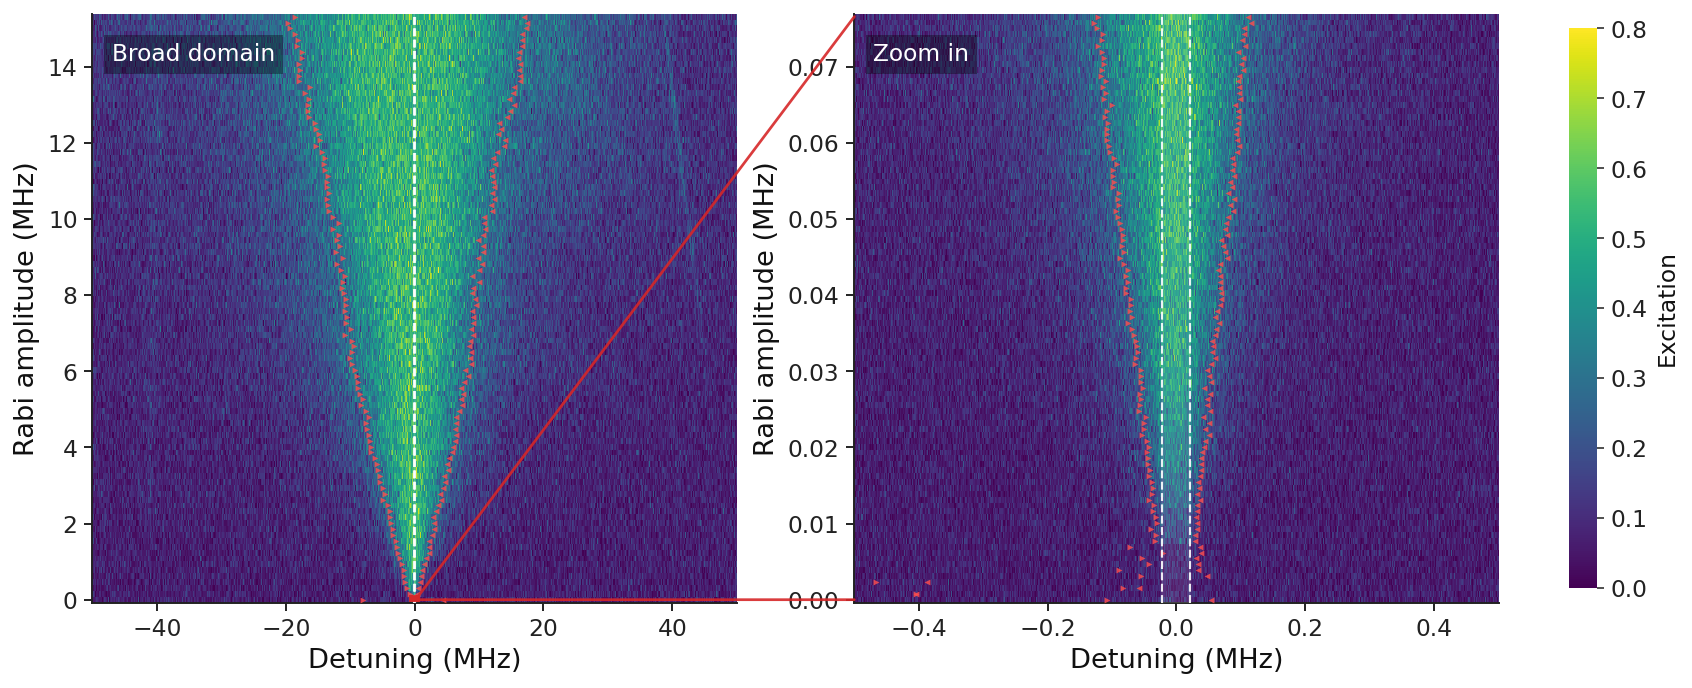

Saved PNG: C:\Users\owner\Developer\ips_plots\figures\00_wide_spec_q1_broad_square_two_sweeps.png
Saved PDF: C:\Users\owner\Developer\ips_plots\figures\00_wide_spec_q1_broad_square_two_sweeps.pdf


In [3]:
vmin = min(float(np.nanmin(sweep["data"].result)) for sweep in SWEEPS)
vmax = max(float(np.nanmax(sweep["data"].result)) for sweep in SWEEPS)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8), constrained_layout=True)

mesh = None
for ax, sweep in zip(axes, SWEEPS):
    data = sweep["data"]
    detuning_mhz = data.detuning_hz / 1e6
    mesh = ax.pcolormesh(
        detuning_mhz,
        sweep["rabi_amp_mhz"],
        data.result.T,
        shading="auto",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
    )
    ax.scatter(
        sweep["fwhm_left_mhz"],
        sweep["fwhm_rabi_amp_mhz"],
        marker=">",
        s=9,
        color="#ff4d4d",
        alpha=0.82,
        linewidths=0,
        zorder=5,
    )
    ax.scatter(
        sweep["fwhm_right_mhz"],
        sweep["fwhm_rabi_amp_mhz"],
        marker="<",
        s=9,
        color="#ff4d4d",
        alpha=0.82,
        linewidths=0,
        zorder=5,
    )
    ax.text(
        0.03,
        0.95,
        sweep["label"],
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=12,
        color="white",
        bbox={"facecolor": "black", "alpha": 0.35, "edgecolor": "none", "pad": 4},
    )
    ax.axvline(-t2_limit_half_width_mhz, color="white", linestyle="--", linewidth=1.1, alpha=0.9, zorder=6)
    ax.axvline(t2_limit_half_width_mhz, color="white", linestyle="--", linewidth=1.1, alpha=0.9, zorder=6)
    ax.axvspan(-t2_limit_half_width_mhz, t2_limit_half_width_mhz, color="white", alpha=0.08, zorder=4)
    ax.set_xlabel("Detuning (MHz)")
    ax.set_ylabel("Rabi amplitude (MHz)")
    polish_axes(ax)

big_sweep = SWEEPS[0]
zoom_sweep = SWEEPS[1]
zoom_x_min = float(np.min(zoom_sweep["data"].detuning_hz / 1e6))
zoom_x_max = float(np.max(zoom_sweep["data"].detuning_hz / 1e6))
zoom_y_min = float(np.min(zoom_sweep["rabi_amp_mhz"]))
zoom_y_max = float(np.max(zoom_sweep["rabi_amp_mhz"]))
axes[0].add_patch(
    plt.Rectangle(
        (zoom_x_min, zoom_y_min),
        zoom_x_max - zoom_x_min,
        zoom_y_max - zoom_y_min,
        fill=False,
        edgecolor="#d62728",
        linewidth=2.0,
        zorder=6,
    )
)

for rect_y, zoom_y in [(zoom_y_min, zoom_y_min), (zoom_y_max, zoom_y_max)]:
    connector = ConnectionPatch(
        xyA=(zoom_x_max, rect_y),
        coordsA=axes[0].transData,
        xyB=(zoom_x_min, zoom_y),
        coordsB=axes[1].transData,
        color="#d62728",
        linewidth=1.4,
        alpha=0.9,
        zorder=7,
        clip_on=False,
    )
    fig.add_artist(connector)

cbar = fig.colorbar(mesh, ax=axes, shrink=0.95)
cbar.set_label("Excitation", fontsize=12)
cbar.outline.set_visible(False)

figure_stem = FIGURES_DIR / f"00_wide_spec_{qubit_name}_broad_square_two_sweeps"
png_path = figure_stem.with_suffix(".png")
pdf_path = figure_stem.with_suffix(".pdf")
fig.canvas.draw()
fig.savefig(png_path, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")

plt.show()

print(f"Saved PNG: {png_path.resolve()}")
print(f"Saved PDF: {pdf_path.resolve()}")